           ce notbook traite le problème lie au Indice de Risque Vectoriel (VRI)

In [2]:
#importations des premiers bibliotheques 
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings('ignore')



#chargement du dataset
df = pd.read_csv('dataset_fusion1_temperatures.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'dataset_fusion1_temperatures.csv'

                               ANALYSE DE FORME(comprendre la structure des donnees)


In [6]:
# taille du dataset 
df.shape

(87240, 26)

In [7]:
# entête 
df.head()

,id,time,weather_code,sunrise,sunset,daylight_duration,sunshine_duration,precipitation_sum,rain_sum,snowfall_sum,...,city,region,latitude,longitude,temperature_2m_max,temperature_2m_min,temperature_2m_mean,apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean
0,1,2020-01-01,3,2020-01-01 06:22:00,2020-01-01 18:13:00,42666.35,36009.06,0.0,0.0,0.0,...,Bafia,Centre,4.75,11.23,33.2,21.9,26.5,34.0,25.6,29.1
1,2,2020-01-02,3,2020-01-02 06:23:00,2020-01-02 18:14:00,42670.10,38715.58,0.0,0.0,0.0,...,Bafia,Centre,4.75,11.23,31.9,21.9,25.9,31.1,23.3,27.0
2,3,2020-01-03,3,2020-01-03 06:23:00,2020-01-03 18:14:00,42674.18,39188.73,0.0,0.0,0.0,...,Bafia,Centre,4.75,11.23,32.0,19.3,25.0,31.7,19.2,25.1
3,4,2020-01-04,3,2020-01-04 06:24:00,2020-01-04 18:15:00,42678.57,39220.31,0.0,0.0,0.0,...,Bafia,Centre,4.75,11.23,31.5,19.1,24.7,32.3,20.7,25.4
4,5,2020-01-05,3,2020-01-05 06:24:00,2020-01-05 18:15:00,42683.27,39251.72,0.0,0.0,0.0,...,Bafia,Centre,4.75,11.23,31.9,19.3,24.8,33.1,20.3,25.9


In [8]:
#types des variables
df.dtypes

id                               int64
time                            object
weather_code                     int64
sunrise                         object
sunset                          object
daylight_duration              float64
sunshine_duration               object
precipitation_sum               object
rain_sum                        object
snowfall_sum                   float64
precipitation_hours            float64
wind_speed_10m_max              object
wind_gusts_10m_max              object
wind_direction_10m_dominant      int64
shortwave_radiation_sum         object
et0_fao_evapotranspiration      object
city                            object
region                          object
latitude                        object
longitude                       object
temperature_2m_max             float64
temperature_2m_min             float64
temperature_2m_mean            float64
apparent_temperature_max       float64
apparent_temperature_min       float64
apparent_temperature_mean

In [9]:
# 2. ANALYSE INITIALE DES VALEURS MANQUANTES

print("\n--- VALEURS MANQUANTES (avant nettoyage) ---")
missing = df.isnull().sum()
missing_pct = df.isnull().mean() * 100
résumé = pd.DataFrame({
    'Manquants': missing,
    'Pourcentage (%)': missing_pct.round(2)
}).query('Manquants > 0').sort_values('Pourcentage (%)', ascending=False)
print(résumé)


--- VALEURS MANQUANTES (avant nettoyage) ---
                           Manquants  Pourcentage (%)
temperature_2m_max              8724             10.0
temperature_2m_min              8724             10.0
temperature_2m_mean             8724             10.0
apparent_temperature_max        8724             10.0
apparent_temperature_min        8724             10.0
apparent_temperature_mean       8724             10.0


In [10]:
# 5. LATITUDE & LONGITUDE

print("\n--- LATITUDE / LONGITUDE ---")

for col in ['latitude', 'longitude']:
    if col in df.columns:
        # Villes sans aucune coordonnée connue
        villes_sans_coord = df.groupby('city')[col].apply(
            lambda x: x.dropna().empty
        )
        villes_problématiques = villes_sans_coord[villes_sans_coord].index.tolist()

        if villes_problématiques:
            print(f" Villes sans '{col}' connue : {villes_problématiques}")
            print(f"   → Renseigne manuellement leurs coordonnées dans le dict 'coords_manquantes' ci-dessous")
        else:
            print(f" Toutes les villes ont au moins une valeur de '{col}'")

        # Référence : première valeur non-nulle par ville
        coord_ref = df.groupby('city')[col].apply(
            lambda x: x.dropna().iloc[0] if not x.dropna().empty else np.nan
        )
        df[col] = df['city'].map(coord_ref)


--- LATITUDE / LONGITUDE ---
 Toutes les villes ont au moins une valeur de 'latitude'
 Toutes les villes ont au moins une valeur de 'longitude'


In [11]:
# 4. CONVERSION DES TYPES

# Colonne time → datetime
if 'time' in df.columns:
    df['time'] = pd.to_datetime(df['time'], errors='coerce')
    print(" Colonne 'time' convertie en datetime")

 Colonne 'time' convertie en datetime


In [13]:
# 6. COLONNES DE TEMPÉRATURE (imputation par médiane )
from sklearn.impute import SimpleImputer

colonnes_temperature = [
    'temperature_2m_max',
    'temperature_2m_min',
    'temperature_2m_mean',
    'apparent_temperature_max',
    'apparent_temperature_min',
    'apparent_temperature_mean'
]

colonnes_temperature = [c for c in colonnes_temperature if c in df.columns]

if colonnes_temperature:
    print("\n--- TEMPÉRATURES (SimpleImputer - médiane) ---")
    imputer_median = SimpleImputer(strategy='median')
    for col in colonnes_temperature:
        avant = df[col].isnull().sum()
        df[col] = imputer_median.fit_transform(df[[col]])
        print(f"  {col:<35} {avant} → {df[col].isnull().sum()} manquants")


--- TEMPÉRATURES (SimpleImputer - médiane) ---
  temperature_2m_max                  8724 → 0 manquants
  temperature_2m_min                  8724 → 0 manquants
  temperature_2m_mean                 8724 → 0 manquants
  apparent_temperature_max            8724 → 0 manquants
  apparent_temperature_min            8724 → 0 manquants
  apparent_temperature_mean           8724 → 0 manquants


In [15]:
# vérification nombre de valeurs manquantes par colonnes 
df.isnull().sum()

id                             0
time                           0
weather_code                   0
sunrise                        0
sunset                         0
daylight_duration              0
sunshine_duration              0
precipitation_sum              0
rain_sum                       0
snowfall_sum                   0
precipitation_hours            0
wind_speed_10m_max             0
wind_gusts_10m_max             0
wind_direction_10m_dominant    0
shortwave_radiation_sum        0
et0_fao_evapotranspiration     0
city                           0
region                         0
latitude                       0
longitude                      0
temperature_2m_max             0
temperature_2m_min             0
temperature_2m_mean            0
apparent_temperature_max       0
apparent_temperature_min       0
apparent_temperature_mean      0
dtype: int64

In [17]:
df.dtypes

id                                      int64
time                           datetime64[ns]
weather_code                            int64
sunrise                                object
sunset                                 object
daylight_duration                     float64
sunshine_duration                      object
precipitation_sum                      object
rain_sum                               object
snowfall_sum                          float64
precipitation_hours                   float64
wind_speed_10m_max                     object
wind_gusts_10m_max                     object
wind_direction_10m_dominant             int64
shortwave_radiation_sum                object
et0_fao_evapotranspiration             object
city                                   object
region                                 object
latitude                               object
longitude                              object
temperature_2m_max                    float64
temperature_2m_min                

                             ANALYSE DE FOND(comprendre le contenu et les relations)

In [20]:
#valeurs statistiques des variables numeriques
df.describe().T

,count,mean,min,25%,50%,75%,max,std
id,87240.0,2617.7,1.0,1148.0,2318.0,3681.0,8724.0,1880.39875
time,87240,2022-12-26 00:00:00.000000256,2020-01-01 00:00:00,2021-06-29 00:00:00,2022-12-26 00:00:00,2024-06-23 00:00:00,2025-12-20 00:00:00,NaN
weather_code,87240.0,40.556385,0.0,3.0,51.0,61.0,65.0,25.739631
daylight_duration,87240.0,43645.372588,41097.38,42970.9,43640.315,44318.5525,46198.17,912.377029
snowfall_sum,87240.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
precipitation_hours,87240.0,5.879184,0.0,0.0,4.0,10.0,24.0,6.05292
wind_direction_10m_dominant,87240.0,185.365326,0.0,108.0,210.0,260.0,360.0,95.19561
temperature_2m_max,87240.0,29.424198,17.7,27.1,29.2,31.2,45.5,3.89815
temperature_2m_min,87240.0,20.024368,9.4,18.2,20.0,21.6,33.7,2.864633
temperature_2m_mean,87240.0,23.952711,15.7,22.1,23.7,25.4,38.2,3.12525


In [22]:
#redondance des variables
df.duplicated().sum()

0

In [24]:
#nous constatons que beaucoup de variables sont de type object alors que ce sont des valeur numeriques entrees.
# Nous allons les convertir en float apres avoir supprimer les espaces.
cat_cols=df.select_dtypes(include='object').columns

In [26]:
cat_cols

Index(['sunrise', 'sunset', 'sunshine_duration', 'precipitation_sum',
       'rain_sum', 'wind_speed_10m_max', 'wind_gusts_10m_max',
       'shortwave_radiation_sum', 'et0_fao_evapotranspiration', 'city',
       'region', 'latitude', 'longitude'],
      dtype='object')

In [28]:

cat_cols = cat_cols.drop(['city', 'region'])  #  on les exclut 

for col in cat_cols:
    df[col] = df[col].astype(str)
    
    df[col] = (
        df[col]
        .str.strip()
        .str.replace(',', '.', regex=False)
        .str.replace(r"[^\d.]", "", regex=True)
    )
    
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Ensuite on convertit city et region en category
df['city']   = df['city'].astype('category')
df['region'] = df['region'].astype('category')

In [29]:
#verification des valeurs manquantes apres conversion
df.isnull().sum()/len(df)

id                             0.0
time                           0.0
weather_code                   0.0
sunrise                        0.0
sunset                         0.0
daylight_duration              0.0
sunshine_duration              0.0
precipitation_sum              0.0
rain_sum                       0.0
snowfall_sum                   0.0
precipitation_hours            0.0
wind_speed_10m_max             0.0
wind_gusts_10m_max             0.0
wind_direction_10m_dominant    0.0
shortwave_radiation_sum        0.0
et0_fao_evapotranspiration     0.0
city                           0.0
region                         0.0
latitude                       0.0
longitude                      0.0
temperature_2m_max             0.0
temperature_2m_min             0.0
temperature_2m_mean            0.0
apparent_temperature_max       0.0
apparent_temperature_min       0.0
apparent_temperature_mean      0.0
dtype: float64

In [30]:
df.dtypes

id                                      int64
time                           datetime64[ns]
weather_code                            int64
sunrise                                 int64
sunset                                  int64
daylight_duration                     float64
sunshine_duration                     float64
precipitation_sum                     float64
rain_sum                              float64
snowfall_sum                          float64
precipitation_hours                   float64
wind_speed_10m_max                    float64
wind_gusts_10m_max                    float64
wind_direction_10m_dominant             int64
shortwave_radiation_sum               float64
et0_fao_evapotranspiration            float64
city                                 category
region                               category
latitude                              float64
longitude                             float64
temperature_2m_max                    float64
temperature_2m_min                

In [34]:

#  Estimation de l'humidité relative (formule Magnus)

def estimer_humidite(T):
    Td = T - 5  # point de rosée estimé (climat tropical camerounais)
    HR = 100 * np.exp((17.625 * Td) / (243.04 + Td)) / \
               np.exp((17.625 * T)  / (243.04 + T))
    return HR

df['relative_humidity_2m_mean'] = estimer_humidite(df['temperature_2m_mean'])
print("\nHumidité estimée :")
print(df['relative_humidity_2m_mean'].describe())


#  Création de is_dry_season

# Saison sèche au Cameroun : Novembre → Mars
df['is_dry_season'] = df['time'].dt.month.isin([11, 12, 1, 2, 3]).astype(int)

print("\nDistribution is_dry_season :")
print(df['is_dry_season'].value_counts())


#  Fonctions gaussiennes

def T_opt(T, sigma=5):
    return np.exp(-((T - 25) ** 2) / (2 * sigma ** 2))

def HR_opt(HR, sigma=15):
    return np.exp(-((HR - 70) ** 2) / (2 * sigma ** 2))


#  Fonction P_opt

def P_opt(precip_sum, precip_hours):
    return np.where(
        (precip_sum > 5) & (precip_hours > 4),
        1.0,
        0.5
    )


#  Calcul du VRI

df['VRI'] = (
    T_opt(df['temperature_2m_mean']) *
    HR_opt(df['relative_humidity_2m_mean']) *
    P_opt(df['precipitation_sum'], df['precipitation_hours']) *
    (1 - df['is_dry_season'])
)


# Vérification et analyse

print("\n--- VRI : statistiques ---")
print(df['VRI'].describe().round(4))
print(f"\nValeurs nulles dans VRI : {df['VRI'].isnull().sum()}")

print("\n--- VRI moyen par ville (classement) ---")
print(df.groupby('city')['VRI'].mean().sort_values(ascending=False).round(4))


Humidité estimée :
count    87240.000000
mean        73.617368
std          0.526806
min         72.163893
25%         73.306308
50%         73.581683
75%         73.869941
max         75.905195
Name: relative_humidity_2m_mean, dtype: float64

Distribution is_dry_season :
is_dry_season
0    51360
1    35880
Name: count, dtype: int64

--- VRI : statistiques ---
count    87240.0000
mean         0.3809
std          0.3735
min          0.0000
25%          0.0000
50%          0.4029
75%          0.7651
max          0.9685
Name: VRI, dtype: float64

Valeurs nulles dans VRI : 0

--- VRI moyen par ville (classement) ---
city
Kribi          0.5346
Edea           0.5131
Loum           0.5003
Wum            0.4967
Mamfe          0.4935
Kumba          0.4853
Douala         0.4843
Ambam          0.4678
Ebolowa        0.4590
Bafia          0.4467
Sangmelima     0.4433
Mbalmayo       0.4396
Akonolinga     0.4357
Limbe          0.4321
Bertoua        0.4277
Batouri        0.4247
Abong-Mbang    0.4211


                                                  MODÉLE POUR PRÉDIRE VIR PAR VILLE 

In [36]:
# nous avons opté pour classivier vir en niveaux de risque 

def classifier_vri(vri):
    if vri == 0:
        return 'Faible'
    elif vri <= 0.3:
        return 'Moyen'
    else:
        return 'Élevé'

df['VRI_classe'] = df['VRI'].apply(classifier_vri)

# Vérification de la distribution
print(df['VRI_classe'].value_counts())
print(df.groupby('city')['VRI_classe'].value_counts())

VRI_classe
Élevé     47528
Faible    35880
Moyen      3832
Name: count, dtype: int64
city         VRI_classe
Abong-Mbang  Élevé         1284
             Faible         897
             Moyen            0
Akonolinga   Élevé         1284
             Faible         897
                           ... 
Yaounde      Faible         897
             Moyen            0
Yokadouma    Élevé         1284
             Faible         897
             Moyen            0
Name: count, Length: 120, dtype: int64


In [38]:
# on constate un énorme desequilibre sur les cas moyen nous devons donc procéder a un réequilibrage pour que nos model n'ignore pas cette catégorie 

print(df['VRI'].describe())
print(df['VRI'].quantile([0.25, 0.50, 0.75, 0.90]))

count    87240.000000
mean         0.380937
std          0.373507
min          0.000000
25%          0.000000
50%          0.402874
75%          0.765073
max          0.968462
Name: VRI, dtype: float64
0.25    0.000000
0.50    0.402874
0.75    0.765073
0.90    0.939594
Name: VRI, dtype: float64


In [40]:
# Seuils basés sur les quantiles réels
# VRI = 0          → Faible  (saison sèche)
# 0 < VRI <= 0.40  → Moyen   (risque modéré)
# VRI > 0.40       → Élevé   (risque élevé)

def classifier_vri(vri):
    if vri == 0:
        return 'Faible'
    elif vri <= 0.40:
        return 'Moyen'
    else:
        return 'Élevé'

df['VRI_classe'] = df['VRI'].apply(classifier_vri)

print(df['VRI_classe'].value_counts())
print(df['VRI_classe'].value_counts(normalize=True).round(3) * 100)

VRI_classe
Élevé     43925
Faible    35880
Moyen      7435
Name: count, dtype: int64
VRI_classe
Élevé     50.3
Faible    41.1
Moyen      8.5
Name: proportion, dtype: float64


    Comme Moyen reste minoritaire, on ajoute class_weight='balanced' pour que les modèles lui accordent plus d'importance 

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report
import pandas as pd

# Encodage  
le = LabelEncoder()
df['city_encoded'] = le.fit_transform(df['city'])

#  Features et cible 
X = df[['temperature_2m_mean', 'relative_humidity_2m_mean',
        'precipitation_sum', 'precipitation_hours',
        'city_encoded']]

y = df['VRI_classe']

#  division  80/20 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#  Normalisation 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

#  Modèles 
modeles = {
    'Random Forest'      : RandomForestClassifier(
                               n_estimators=100,
                               class_weight='balanced',
                               random_state=42),
    'Gradient Boosting'  : GradientBoostingClassifier(
                               n_estimators=100,
                               random_state=42),
    'Logistic Regression': LogisticRegression(
                               max_iter=1000,
                               class_weight='balanced',
                               random_state=42)
}

#  Entraînement  évaluation 
resultats = {}

for nom, modele in modeles.items():
    # Logistic Regression utilise les données normalisées
    if nom == 'Logistic Regression':
        modele.fit(X_train_scaled, y_train)
        y_pred = modele.predict(X_test_scaled)
    else:
        modele.fit(X_train, y_train)
        y_pred = modele.predict(X_test)

    
    print(f"  {nom}")

    print(classification_report(y_test, y_pred,
          target_names=['Élevé', 'Faible', 'Moyen']))

    resultats[nom] = y_pred

  Random Forest
              precision    recall  f1-score   support

       Élevé       0.76      0.72      0.74      7176
      Faible       0.68      0.90      0.77      1487
       Moyen       0.84      0.83      0.84      8785

    accuracy                           0.79     17448
   macro avg       0.76      0.82      0.78     17448
weighted avg       0.80      0.79      0.79     17448

  Gradient Boosting
              precision    recall  f1-score   support

       Élevé       0.80      0.74      0.77      7176
      Faible       0.81      0.78      0.79      1487
       Moyen       0.83      0.88      0.86      8785

    accuracy                           0.82     17448
   macro avg       0.81      0.80      0.81     17448
weighted avg       0.81      0.82      0.81     17448

  Logistic Regression
              precision    recall  f1-score   support

       Élevé       0.68      0.72      0.70      7176
      Faible       0.47      0.70      0.56      1487
       Moyen     

In [45]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [3, 5, 7],
    'learning_rate'   : [0.05, 0.1, 0.2],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=5,               # validation croisée 5 folds
    scoring='f1_macro', # optimiser le F1 macro (équilibré)
    n_jobs=-1,          # utiliser tous les CPU
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Meilleurs paramètres :", grid_search.best_params_)
print("Meilleur F1 macro    :", round(grid_search.best_score_, 4))

# Évaluation du meilleur modèle
meilleur_gb = grid_search.best_estimator_
y_pred_best = meilleur_gb.predict(X_test)
print(classification_report(y_test, y_pred_best,
      target_names=['Élevé', 'Faible', 'Moyen']))

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Meilleurs paramètres : {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}
Meilleur F1 macro    : 0.8183
              precision    recall  f1-score   support

       Élevé       0.79      0.78      0.78      7176
      Faible       0.81      0.77      0.79      1487
       Moyen       0.86      0.86      0.86      8785

    accuracy                           0.82     17448
   macro avg       0.82      0.81      0.81     17448
weighted avg       0.82      0.82      0.82     17448



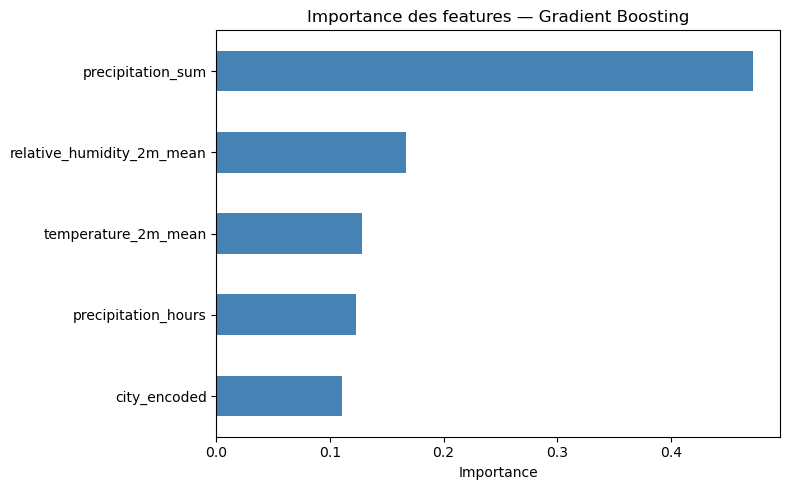


--- Prédiction du niveau de risque VRI par ville ---
       city VRI_prédit
Abong-Mbang     Faible
 Akonolinga     Faible
      Mamfe     Faible
     Maroua     Faible
   Mbalmayo     Faible
    Mbengwi     Faible
     Mbouda     Faible
   Meiganga     Faible
     Mokolo     Faible
 Ngaoundere     Faible
 Nkongsamba     Faible
       Poli     Faible
 Sangmelima     Faible
     Tibati     Faible
    Tignere     Faible
    Touboro     Faible
        Wum     Faible
     Yagoua     Faible
    Yaounde     Faible
       Loum     Faible
      Limbe     Faible
      Kumbo     Faible
     Douala     Faible
      Ambam     Faible
      Bafia     Faible
  Bafoussam     Faible
    Bamenda     Faible
    Batouri     Faible
    Bertoua     Faible
       Buea     Faible
    Dschang     Faible
      Kumba     Faible
    Ebolowa     Faible
       Edea     Faible
    Foumban     Faible
     Garoua     Faible
     Guider     Faible
   Kousseri     Faible
      Kribi     Faible
  Yokadouma     Faible


In [52]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Importance des features 
features_names = ['temperature_2m_mean', 'relative_humidity_2m_mean',
                  'precipitation_sum', 'precipitation_hours', 'city_encoded']

importances = pd.Series(
    meilleur_gb.feature_importances_,
    index=features_names
).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='steelblue')
plt.title('Importance des features — Gradient Boosting')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# 2. Forecasting — VRI prédit par ville 
dernières_données = df.groupby('city').last().reset_index()

X_futur = dernières_données[['temperature_2m_mean', 'relative_humidity_2m_mean',
                              'precipitation_sum', 'precipitation_hours',
                              'city_encoded']]

dernières_données['VRI_prédit'] = meilleur_gb.predict(X_futur)

print("\n--- Prédiction du niveau de risque VRI par ville ---")
print(dernières_données[['city', 'VRI_prédit']]
      .sort_values('VRI_prédit', ascending=False)
      .to_string(index=False))

In [56]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import learning_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [58]:
#  SAUVEGARDE DU MODÈLE

joblib.dump(meilleur_gb, 'modele_vri_gradient_boosting.pkl')
joblib.dump(scaler,      'scaler_vri.pkl')
joblib.dump(le,          'label_encoder_city.pkl')

print(" Modèle sauvegardé → modele_vri_gradient_boosting.pkl")
print(" Scaler sauvegardé → scaler_vri.pkl")
print(" LabelEncoder sauvegardé → label_encoder_city.pkl")

# Vérification — rechargement
modele_charge = joblib.load('modele_vri_gradient_boosting.pkl')
print(" Modèle rechargé avec succès")


 Modèle sauvegardé → modele_vri_gradient_boosting.pkl
 Scaler sauvegardé → scaler_vri.pkl
 LabelEncoder sauvegardé → label_encoder_city.pkl
 Modèle rechargé avec succès


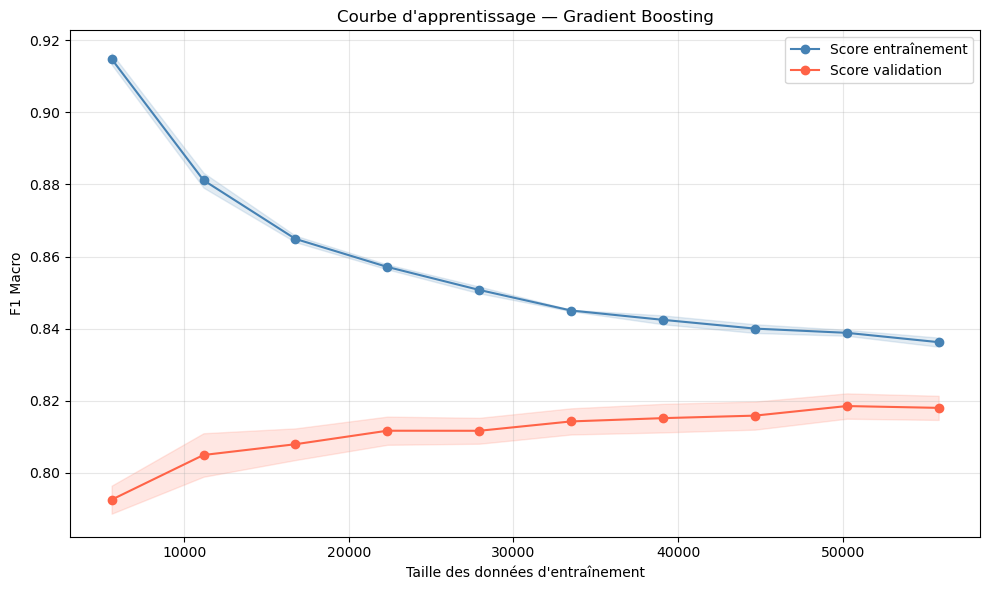

In [64]:
#  COURBE D'APPRENTISSAGE

train_sizes, train_scores, test_scores = learning_curve(
    meilleur_gb, X_train, y_train,
    cv=5,
    scoring='f1_macro',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
test_mean  = test_scores.mean(axis=1)
test_std   = test_scores.std(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Score entraînement')
plt.plot(train_sizes, test_mean,  'o-', color='tomato',    label='Score validation')
plt.fill_between(train_sizes,
                 train_mean - train_std,
                 train_mean + train_std, alpha=0.15, color='steelblue')
plt.fill_between(train_sizes,
                 test_mean - test_std,
                 test_mean + test_std,   alpha=0.15, color='tomato')
plt.title('Courbe d\'apprentissage — Gradient Boosting')
plt.xlabel('Taille des données d\'entraînement')
plt.ylabel('F1 Macro')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('courbe_apprentissage.png', dpi=150)
plt.show()


<Figure size 800x600 with 0 Axes>

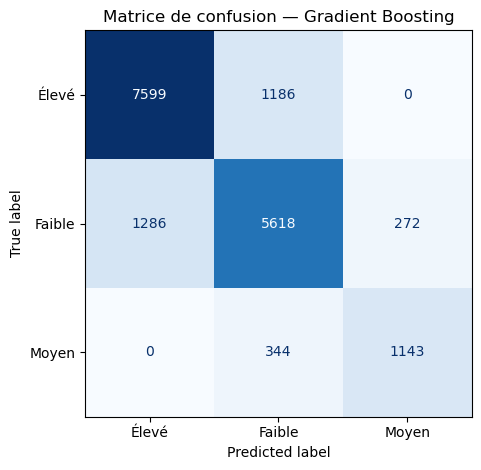

In [61]:
#  MATRICE DE CONFUSION

cm = confusion_matrix(y_test, y_pred_best, labels=['Élevé', 'Faible', 'Moyen'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Élevé', 'Faible', 'Moyen'])
plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', colorbar=False)
plt.title('Matrice de confusion — Gradient Boosting')
plt.tight_layout()
plt.savefig('matrice_confusion.png', dpi=150)
plt.show()


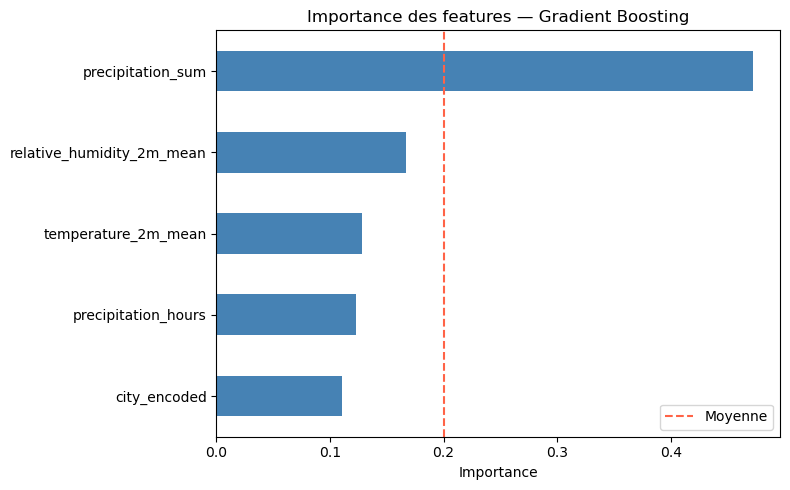

In [62]:
#  IMPORTANCE DES FEATURES

features_names = ['temperature_2m_mean', 'relative_humidity_2m_mean',
                  'precipitation_sum', 'precipitation_hours', 'city_encoded']

importances = pd.Series(meilleur_gb.feature_importances_,
                        index=features_names).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='steelblue')
plt.title('Importance des features — Gradient Boosting')
plt.xlabel('Importance')
plt.axvline(x=importances.mean(), color='tomato',
            linestyle='--', label='Moyenne')
plt.legend()
plt.tight_layout()
plt.savefig('importance_features.png', dpi=150)
plt.show()

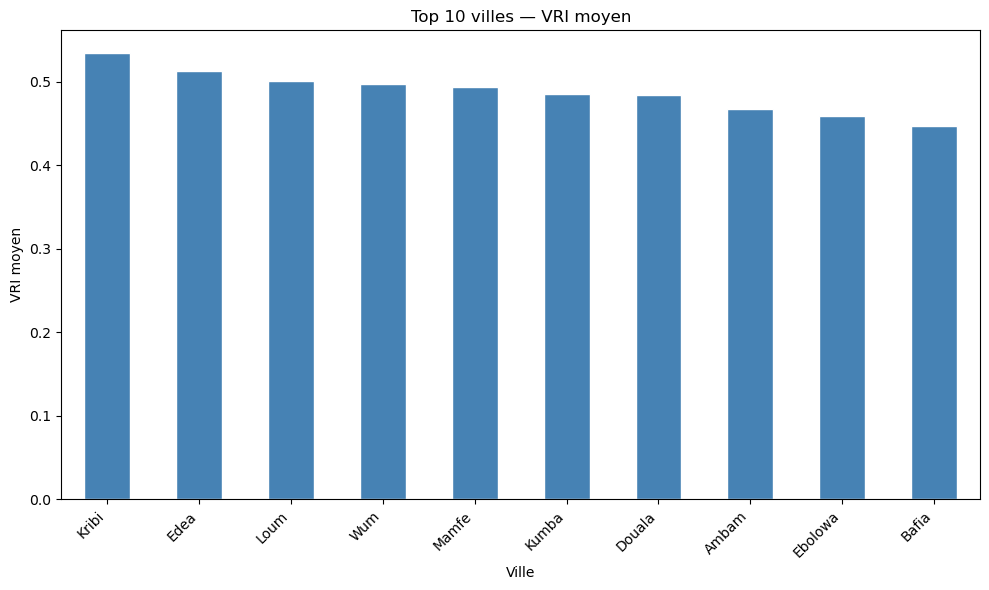

In [63]:


#  DISTRIBUTION DU VRI PAR VILLE (TOP 10)

top10 = df.groupby('city')['VRI'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top10.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Top 10 villes — VRI moyen')
plt.xlabel('Ville')
plt.ylabel('VRI moyen')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('vri_par_ville.png', dpi=150)
plt.show()

# amélioration 

In [ ]:
from sklearn.preprocessing import LabelEncoder

#  Features temporelles 
df['mois']      = df['time'].dt.month
df['trimestre'] = df['time'].dt.quarter
df['jour_annee']= df['time'].dt.dayofyear  # 1 → 365, capture la saisonnalité


In [ ]:
#  Encodage cyclique du mois 
# Janvier et Décembre sont "proches" — le sinus/cosinus capture ça
df['mois_sin'] = np.sin(2 * np.pi * df['mois'] / 12)
df['mois_cos'] = np.cos(2 * np.pi * df['mois'] / 12)


In [ ]:
#  Encodage ville par fréquence 
freq_city = df['city'].value_counts(normalize=True)
df['city_freq'] = df['city'].map(freq_city)


In [ ]:

#  Features climatiques dérivées 
df['amplitude_thermique'] = df['temperature_2m_max'] - df['temperature_2m_min']
df['pluie_intense']       = ((df['precipitation_sum'] > 5) & 
                              (df['precipitation_hours'] > 4)).astype(int)

print(" Nouvelles features créées :")
nouvelles = ['mois', 'trimestre', 'jour_annee', 'mois_sin', 'mois_cos',
             'city_freq', 'amplitude_thermique', 'pluie_intense']
print(df[nouvelles].describe().round(3))

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

features = [
    
    'temperature_2m_mean',
    'relative_humidity_2m_mean',
    'precipitation_sum',
    'precipitation_hours',
    'mois_sin',
    'mois_cos',
    'jour_annee',
    'trimestre',
    'amplitude_thermique',
    'pluie_intense',
    'city_freq',
    'is_dry_season'
]

X = df[features]
y = df['VRI_classe']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report

# nouvel entrainement 
gb_ameliore = GradientBoostingClassifier(
    learning_rate    = 0.1,
    max_depth        = 5,
    min_samples_split= 2,
    n_estimators     = 200,
    random_state     = 42
)

gb_ameliore.fit(X_train, y_train)
y_pred = gb_ameliore.predict(X_test)

print("\n--- Résultats GB amélioré ---")
print(classification_report(y_test, y_pred,
      target_names=['Élevé', 'Faible', 'Moyen']))

In [ ]:
# Tableau comparatif
from sklearn.metrics import f1_score, accuracy_score

resultats = pd.DataFrame({
    'Modèle'   : ['GB ancien (5 features)', 'GB amélioré (11 features)'],
    'Accuracy' : [0.82, accuracy_score(y_test, y_pred).round(4)],
    'F1 Macro' : [0.81, f1_score(y_test, y_pred, average='macro').round(4)],
    'F1 Élevé' : [0.77, f1_score(y_test, y_pred, average=None)[0].round(4)],
    'F1 Faible': [0.79, f1_score(y_test, y_pred, average=None)[1].round(4)],
    'F1 Moyen' : [0.86, f1_score(y_test, y_pred, average=None)[2].round(4)]
})

print(resultats.to_string(index=False))

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score


#  FEATURES CLIMATIQUES PAR VILLE (agrégation)

features_clustering = [
    'temperature_2m_mean',
    'precipitation_sum',
    'wind_speed_10m_max',
    'shortwave_radiation_sum',
    'et0_fao_evapotranspiration',
    'sunshine_duration',
    'amplitude_thermique',
    'humidity_2m_mean' if 'humidity_2m_mean' in df.columns else 'relative_humidity_2m_mean'
]

# Garder uniquement les colonnes existantes
features_clustering = [c for c in features_clustering if c in df.columns]
print("Features utilisées :", features_clustering)

# Profil moyen par ville
profil_villes = df.groupby('city')[features_clustering].mean()
print(f"\n{profil_villes.shape[0]} villes × {profil_villes.shape[1]} features")
print(profil_villes.round(2))


# 2. NORMALISATION

scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(profil_villes)
X_cluster_df = pd.DataFrame(X_cluster,
                             index=profil_villes.index,
                             columns=features_clustering)


# 3. CHOIX DU NOMBRE DE CLUSTERS — Méthode Elbow + Silhouette

inerties    = []
silhouettes = []
K_range     = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    inerties.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Courbe Elbow
axes[0].plot(K_range, inerties, 'o-', color='steelblue', linewidth=2)
axes[0].set_title('Méthode Elbow — Inertie par K')
axes[0].set_xlabel('Nombre de clusters (K)')
axes[0].set_ylabel('Inertie')
axes[0].grid(True, alpha=0.3)

# Courbe Silhouette
axes[1].plot(K_range, silhouettes, 'o-', color='tomato', linewidth=2)
axes[1].set_title('Score Silhouette par K')
axes[1].set_xlabel('Nombre de clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150)
plt.show()

print("\nScores Silhouette :")
for k, s in zip(K_range, silhouettes):
    print(f"  K={k} → {s:.4f}")


# 4. ENTRAÎNEMENT DU MODÈLE FINAL
#    (choisir K après avoir vu les courbes)

K_optimal = 4  # ← ajuste après avoir vu les courbes

kmeans = KMeans(n_clusters=K_optimal, random_state=42, n_init=10)
profil_villes['Cluster'] = kmeans.fit_predict(X_cluster)

print(f"\n--- Répartition des villes par cluster (K={K_optimal}) ---")
print(profil_villes['Cluster'].value_counts().sort_index())

print("\n--- Villes par cluster ---")
for c in range(K_optimal):
    villes = profil_villes[profil_villes['Cluster'] == c].index.tolist()
    print(f"\nCluster {c} ({len(villes)} villes) : {villes}")


# 5. PROFIL MOYEN PAR CLUSTER

profil_clusters = profil_villes.groupby('Cluster')[features_clustering].mean().round(2)
print("\n--- Profil moyen par cluster ---")
print(profil_clusters)

# Heatmap des profils
plt.figure(figsize=(12, 5))
sns.heatmap(
    pd.DataFrame(scaler_cluster.transform(profil_clusters),
                 index=profil_clusters.index,
                 columns=features_clustering),
    annot=True, fmt='.2f', cmap='RdYlGn_r',
    linewidths=0.5, cbar_kws={'label': 'Valeur normalisée'}
)
plt.title('Profil climatique moyen par cluster')
plt.xlabel('Features climatiques')
plt.ylabel('Cluster')
plt.tight_layout()
plt.savefig('profil_clusters.png', dpi=150)
plt.show()


# 6. VISUALISATION PCA (2D)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)

variance_expliquee = pca.explained_variance_ratio_ * 100
print(f"\nVariance expliquée par PCA : "
      f"PC1={variance_expliquee[0]:.1f}%, PC2={variance_expliquee[1]:.1f}%")

couleurs = ['steelblue', 'tomato', 'seagreen', 'darkorange',
            'purple', 'brown', 'pink', 'gray']

plt.figure(figsize=(12, 8))
for c in range(K_optimal):
    mask = profil_villes['Cluster'] == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=couleurs[c], label=f'Cluster {c}',
                s=120, edgecolors='white', linewidth=0.8)
    # Annoter chaque ville
    for ville in profil_villes[mask].index:
        idx = profil_villes.index.get_loc(ville)
        plt.annotate(ville, (X_pca[idx, 0], X_pca[idx, 1]),
                     fontsize=7, ha='center', va='bottom',
                     xytext=(0, 5), textcoords='offset points')

plt.title(f'Clustering des villes camerounaises — PCA 2D (K={K_optimal})\n'
          f'Variance expliquée : {sum(variance_expliquee):.1f}%')
plt.xlabel(f'PC1 ({variance_expliquee[0]:.1f}%)')
plt.ylabel(f'PC2 ({variance_expliquee[1]:.1f}%)')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('clustering_pca.png', dpi=150)
plt.show()


# 7. AJOUTER LE CLUSTER AU DATAFRAME PRINCIPAL

df = df.merge(
    profil_villes[['Cluster']].reset_index(),
    on='city', how='left'
)
df['Cluster'] = df['Cluster'].astype('category')
print("\n✅ Colonne 'Cluster' ajoutée au DataFrame principal")
print(df['Cluster'].value_counts().sort_index())